In [1]:
import pandas as pd
import numpy as np

In [2]:
# Dataset
# Read in the data
df = pd.read_csv('../dataset/tweet_data/tweet_data.csv')

In [3]:
df.sample(10)

,textID,tweet_text,sentiment
7509,1965019317,.....headache,negative
9125,1966209786,i hate my presentation hahah whatever im glad...,positive
8539,1965873018,@brittaniethekid But he's so adorable.,positive
3779,1961919744,The Oddo's grandfather passed away in his sleep,negative
11395,1694812668,"iï¿½m boring - bad weather today, watchingn al...",negative
4750,1962779908,http://twitpic.com/674p1 - @JTHawthorne this i...,negative
12416,1695443225,@petercoffin Maybe if we pass a lay making the...,negative
18195,1753727134,Good Morning! Looking Forward To Listening To ...,positive
14058,1751538725,"About to pik out my hair, braid it up, scrub o...",positive
14477,1751853903,@ShepardsFaith I shall annoyingly tweet at you...,negative


## Visualise data

In [4]:
import matplotlib.pyplot as plt

           textID  tweet_text
sentiment                    
negative     8830        8830
positive     9897        9897


<BarContainer object of 2 artists>

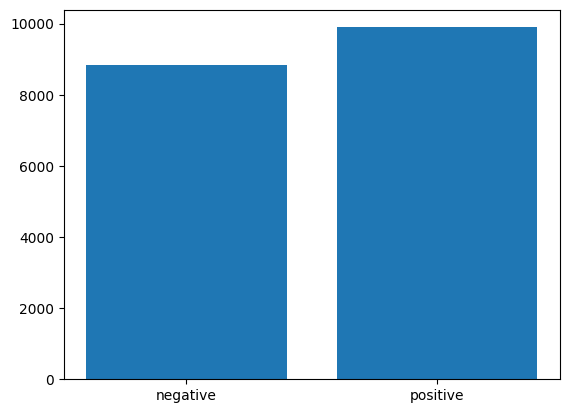

In [5]:
sentiment_count = df.groupby('sentiment').count()
# show number of count of positive and negative
print(sentiment_count)
# Showing the bar plot of positive and negative
plt.bar(sentiment_count.index.values, sentiment_count['tweet_text'])

# Using module to show most used words for pos and neg tweets

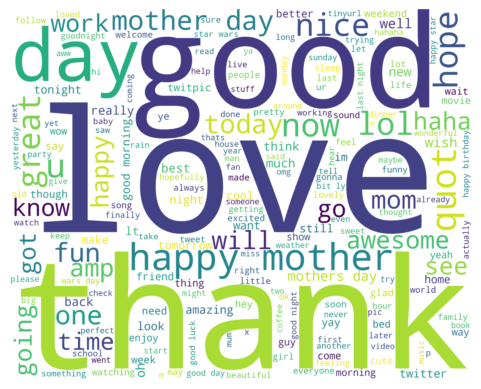

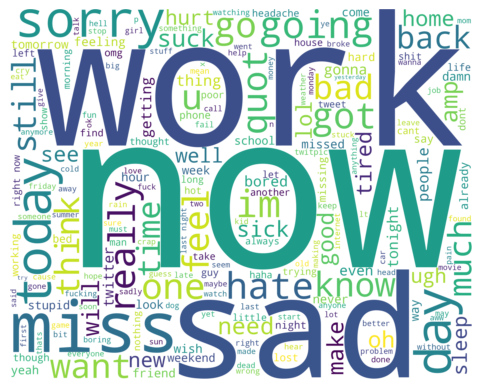

In [6]:
from wordcloud import WordCloud

positive_tweets = df[df['sentiment'] == 'positive']
negative_tweets = df[df['sentiment'] == 'negative']

txt_positive = " ".join(tweet.lower() for tweet in positive_tweets['tweet_text'])
txt_negative = " ".join(tweet.lower() for tweet in negative_tweets['tweet_text'])

# Generate a word cloud image
wordcloud_positive = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_positive)
wordcloud_negative = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_negative)

# Display the generated image:
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.show()



# Text Normalization

In [7]:
import re

In [8]:
example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. 😊 #food #greatfood #BESTFOOD!!"

In [9]:
# Remove emojis
import emoji

In [11]:

def convert_emoji_to_text(string):
    string = emoji.demojize(string) # Converting the emoji to their word meaning
    string = string.replace(":"," ") # Replacing the colon symbol with a space
    return string

print(convert_emoji_to_text(example))


Tom loved this fooooooood spot. This is their website for more info  https //www.examplefoodspot.com.  smiling_face_with_smiling_eyes  #food #greatfood #BESTFOOD!!


In [16]:
# Remove links
def remove_links(string, replace_with=""):
    string = re.sub('(http|https):\/\/\S+', replace_with, string) # regex to remove any links starting with http or https
    return string
print (remove_links(example))

Tom loved this fooooooood spot. This is their website for more info:  😊 #food #greatfood #BESTFOOD!!


In [20]:
# Remove hashtags
def remove_hashtags(string, replace_with=""):
    string = re.sub('#+', replace_with, string) # regex to remove any hashtags
    return string

print (remove_hashtags(example))

Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. 😊 food greatfood BESTFOOD!!
